In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn.metrics as metrics
import os

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import  RandomForestClassifier
from sklearn.ensemble import  RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.metrics import accuracy_score, classification_report

In [6]:
df = pd.read_csv("Location1.csv")
df.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,1/2/2017 0:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635
1,1/2/2017 1:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424
2,1/2/2017 2:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214
3,1/2/2017 3:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003
4,1/2/2017 4:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793


In [7]:
unique_ = df['Power'].unique()
unique_

array([0.1635, 0.1424, 0.1214, ..., 0.9511, 0.6392, 0.3268])

In [8]:
df.columns

Index(['Time', 'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
       'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
       'winddirection_100m', 'windgusts_10m', 'Power'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df= df.drop_duplicates()
print("DataFrame after dropping duplicates:")
print(df)

DataFrame after dropping duplicates:
                   Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0         1/2/2017 0:00            28.5                   85         24.5   
1         1/2/2017 1:00            28.4                   86         24.7   
2         1/2/2017 2:00            26.8                   91         24.5   
3         1/2/2017 3:00            27.4                   88         24.3   
4         1/2/2017 4:00            27.3                   88         24.1   
...                 ...             ...                  ...          ...   
43795  12/31/2021 19:00            34.1                   94         32.5   
43796  12/31/2021 20:00            34.8                   94         33.4   
43797  12/31/2021 21:00            34.1                   95         33.0   
43798  12/31/2021 22:00            34.4                   96         33.5   
43799  12/31/2021 23:00            35.0                   97         34.2   

       windspeed_10m  windspeed_100m  

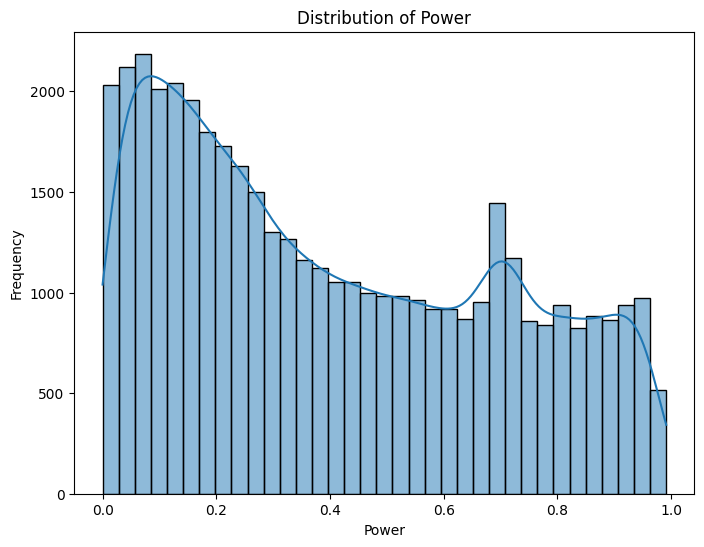

In [11]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Power'], kde=True)
plt.title('Distribution of Power')
plt.xlabel('Power')
plt.ylabel('Frequency')
plt.show()

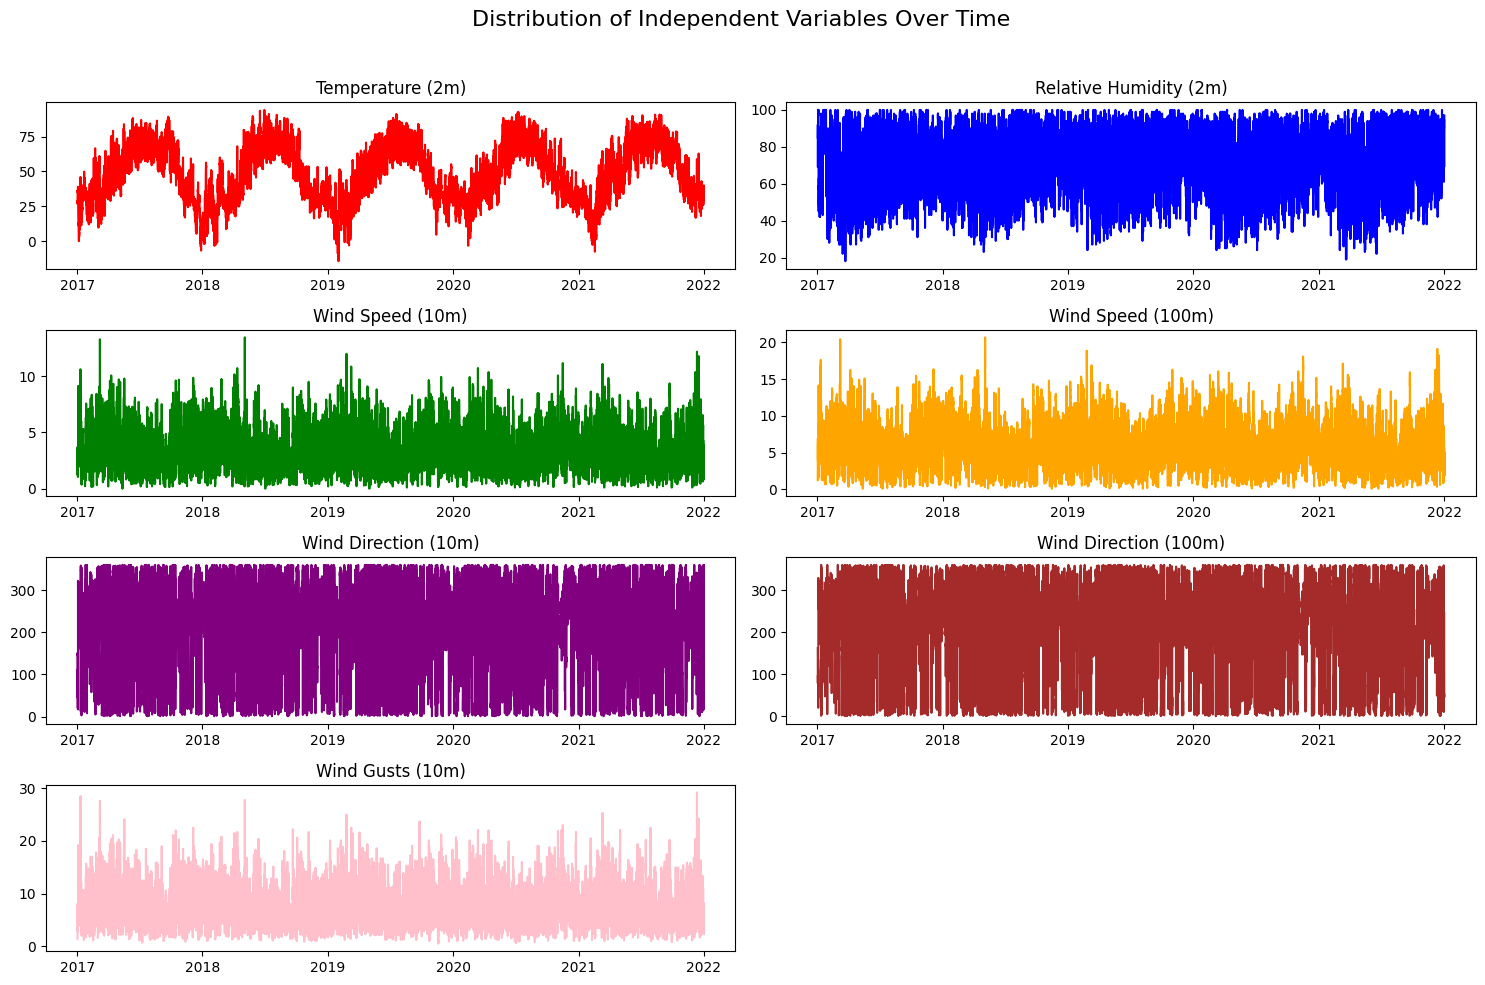

In [12]:
df['Time'] = pd.to_datetime(df['Time'])

# Create the figure and subplots
fig, axs = plt.subplots(4, 2, figsize=(15, 10))
fig.suptitle('Distribution of Independent Variables Over Time', fontsize=16)

# Plot each variable
axs[0, 0].plot(df['Time'], df['temperature_2m'], color='red')
axs[0, 0].set_title('Temperature (2m)')
axs[0, 1].plot(df['Time'], df['relativehumidity_2m'], color='blue')
axs[0, 1].set_title('Relative Humidity (2m)')

axs[1, 0].plot(df['Time'], df['windspeed_10m'], color='green')
axs[1, 0].set_title('Wind Speed (10m)')
axs[1, 1].plot(df['Time'], df['windspeed_100m'], color='orange')
axs[1, 1].set_title('Wind Speed (100m)')

axs[2, 0].plot(df['Time'], df['winddirection_10m'], color='purple')
axs[2, 0].set_title('Wind Direction (10m)')
axs[2, 1].plot(df['Time'], df['winddirection_100m'], color='brown')
axs[2, 1].set_title('Wind Direction (100m)')

axs[3, 0].plot(df['Time'], df['windgusts_10m'], color='pink')
axs[3, 0].set_title('Wind Gusts (10m)')

# Hide the last empty subplot
axs[3, 1].axis('off')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


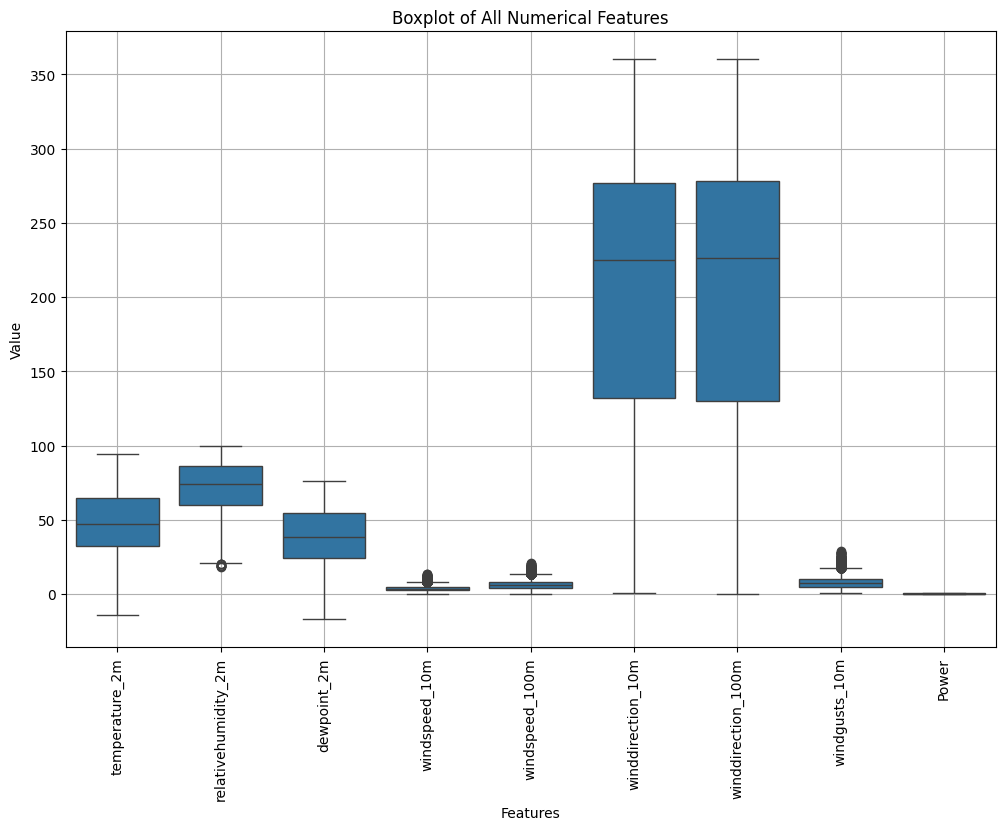

In [13]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Melt the dataframe to long format suitable for seaborn boxplot
df_melted = pd.melt(df[numerical_columns])

# Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='variable', y='value', data=df_melted)
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.title('Boxplot of All Numerical Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.grid(True)
plt.show()

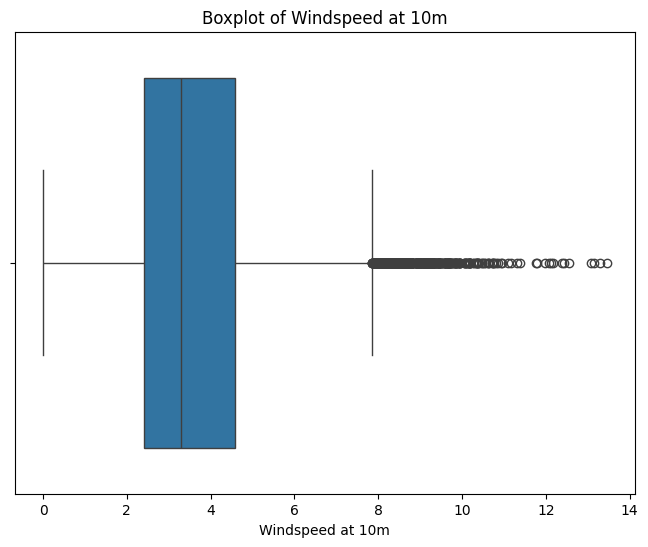

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_10m', data=df)
plt.title('Boxplot of Windspeed at 10m')
plt.xlabel('Windspeed at 10m')
plt.show()

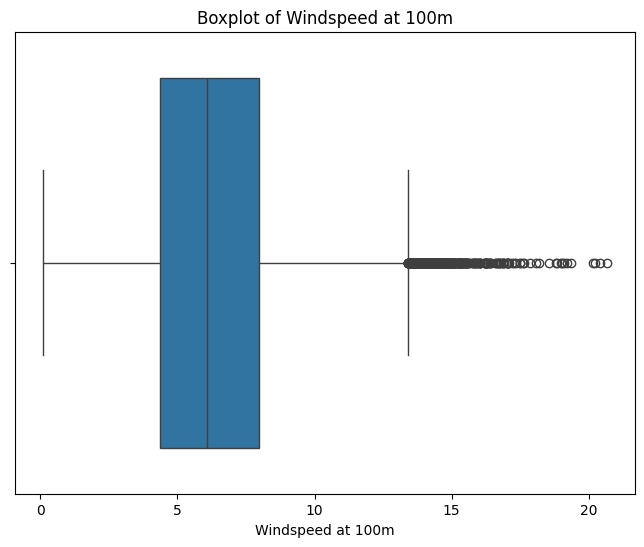

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=df)
plt.title('Boxplot of Windspeed at 100m')
plt.xlabel('Windspeed at 100m')
plt.show()

In [16]:
from scipy import stats
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

z_scores = np.abs(stats.zscore(numeric_df))

data_cleaned = df[(z_scores < 3).all(axis=1)]

In [17]:
print("Original DataFrame shape:", df.shape)
print("DataFrame shape after removing outliers:", data_cleaned.shape)

Original DataFrame shape: (43800, 10)
DataFrame shape after removing outliers: (43344, 10)


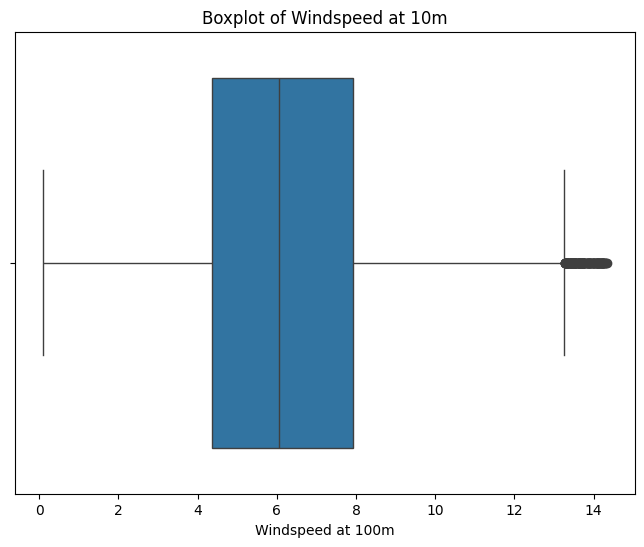

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=data_cleaned)
plt.title('Boxplot of Windspeed at 10m')
plt.xlabel('Windspeed at 100m')
plt.show()

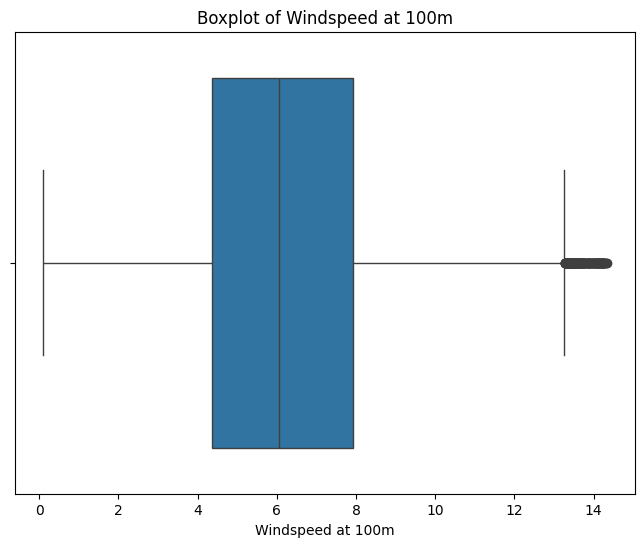

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=data_cleaned)
plt.title('Boxplot of Windspeed at 100m')
plt.xlabel('Windspeed at 100m')
plt.show()

In [20]:
categorical_columns = data_cleaned.select_dtypes(include=['object', 'category']).columns
categorical_columns

Index([], dtype='object')

In [21]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming df is your DataFrame
le = LabelEncoder()

# Encode the necessary columns
data_cleaned['Time'] = le.fit_transform(data_cleaned['Time'])
data_cleaned['temperature_2m'] = le.fit_transform(data_cleaned['temperature_2m'])
data_cleaned['relativehumidity_2m'] = le.fit_transform(data_cleaned['relativehumidity_2m'])
data_cleaned['dewpoint_2m'] = le.fit_transform(data_cleaned['dewpoint_2m'])
data_cleaned['windspeed_10m'] = le.fit_transform(data_cleaned['windspeed_10m'])
data_cleaned['windspeed_100m'] = le.fit_transform(data_cleaned['windspeed_100m'])
data_cleaned['winddirection_10m'] = le.fit_transform(data_cleaned['winddirection_10m'])
data_cleaned['winddirection_100m'] = le.fit_transform(data_cleaned['winddirection_10m'])
data_cleaned['windgusts_10m'] = le.fit_transform(data_cleaned['windgusts_10m'])
data_cleaned['Power'] = le.fit_transform(data_cleaned['Power'])


/tmp/ipython-input-3802273176.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Time'] = le.fit_transform(data_cleaned['Time'])
/tmp/ipython-input-3802273176.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['temperature_2m'] = le.fit_transform(data_cleaned['temperature_2m'])
/tmp/ipython-input-3802273176.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [22]:
X=data_cleaned.drop(columns='Power')
X=data_cleaned.drop(columns='Time')
X

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,345,63,378,72,57,145,145,9,1632
1,344,64,380,122,301,150,150,39,1421
2,328,69,378,61,186,147,147,27,1211
3,334,66,376,61,178,57,57,11,1000
4,333,66,374,159,345,57,57,35,790
...,...,...,...,...,...,...,...,...,...
43795,401,72,458,42,108,52,52,20,1792
43796,408,72,467,163,332,55,55,43,2062
43797,401,73,463,48,102,359,359,38,2330
43798,404,74,468,152,363,44,44,37,2600


In [23]:
y = np.asarray(data_cleaned['Power'])

In [24]:
# Remove outliers in 'Power' target using IQR
Q1 = data_cleaned['Power'].quantile(0.25)
Q3 = data_cleaned['Power'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned1 = data_cleaned[(data_cleaned['Power'] > lower_bound) & (data_cleaned['Power'] < upper_bound)]

In [42]:
from xgboost import XGBRegressor

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


In [52]:
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

I applied different splits like 40:60, 30:70, and 20:80 — just changed the test_size value and ran the cell again.

In [53]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Calculate standard deviations
errors = y_test - y_pred
mae_sd = np.std(np.abs(errors))
mse_sd = np.std(errors ** 2)
rmse_sd = np.std(np.sqrt(errors ** 2))
r2_sd = np.std(errors / np.std(y_test))  # Approximation of R² variability

# Print with ±
print(f'R-squared: {r2:.3f} ± {r2_sd:.3f}')
print(f'Mean Absolute Error (MAE): {mae:.3f} ± {mae_sd:.3f}')
print(f'Mean Squared Error (MSE): {mse:.3f} ± {mse_sd:.3f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.3f} ± {rmse_sd:.3f}')

R-squared: 1.000 ± 0.007
Mean Absolute Error (MAE): 15.949 ± 12.353
Mean Squared Error (MSE): 406.964 ± 580.376
Root Mean Squared Error (RMSE): 20.173 ± 12.353


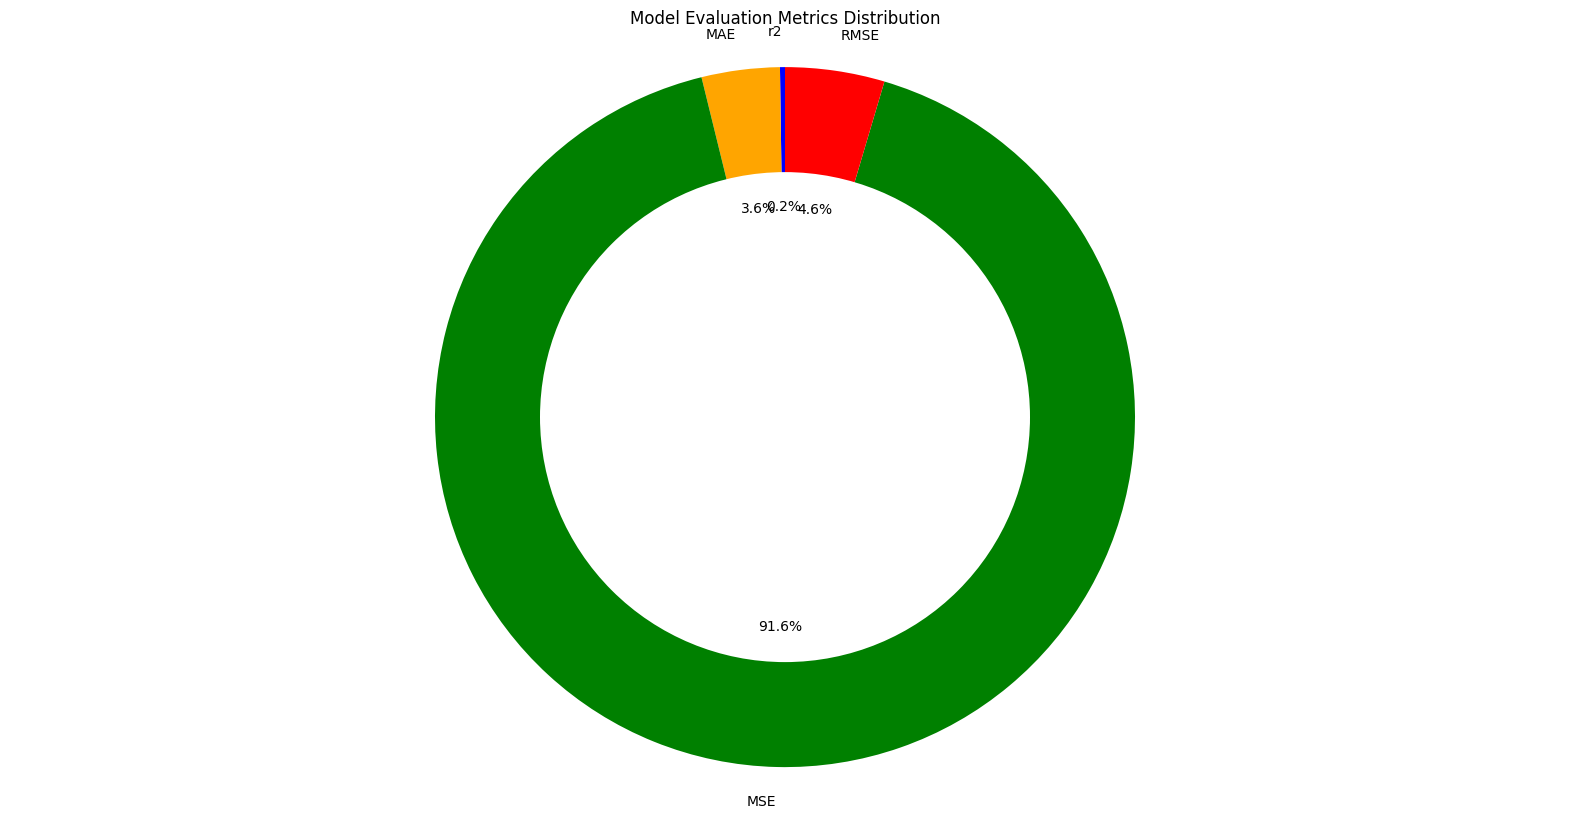

In [29]:
import matplotlib.pyplot as plt

# Prepare data for visualization
metrics = ['r2', 'MAE', 'MSE', 'RMSE']
scores = [r2, mae, mse, rmse]

# Create a pie chart
plt.figure(figsize=(20, 10))
plt.pie(scores, labels=metrics, autopct='%1.1f%%', startangle=90, colors=['blue', 'orange', 'green', 'red'])

# Draw a circle in the center to make it look like a donut chart (optional)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Model Evaluation Metrics Distribution')
plt.show()

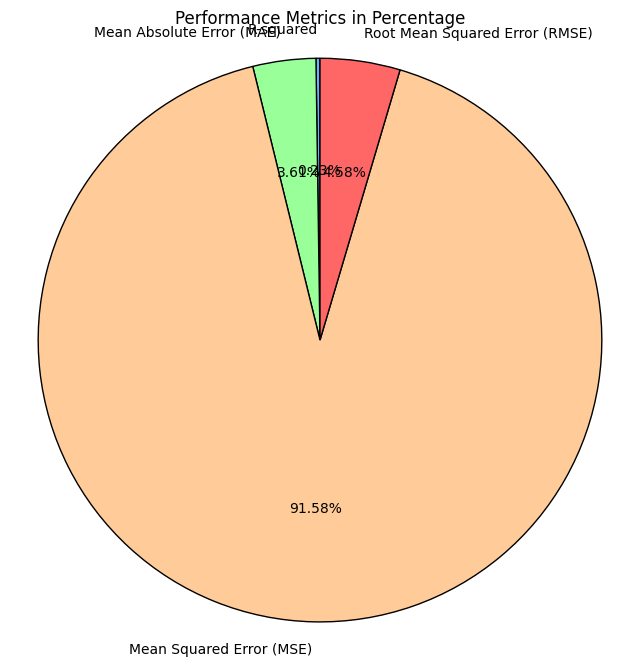

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Assuming you have the predicted and actual values
# y_test = actual values, y_pred = predicted values

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Create the performance metrics list
metrics = [r2, mae, mse, rmse]
metrics_names = ['R-squared', 'Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)']

# Normalize the values to get the percentage for the pie chart
total = sum(metrics)
percentages = [metric / total * 100 for metric in metrics]

# Set color palette for the pie chart
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff6666']

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(percentages, labels=metrics_names, autopct='%1.2f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Performance Metrics in Percentage')

# Display the pie chart
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.show()


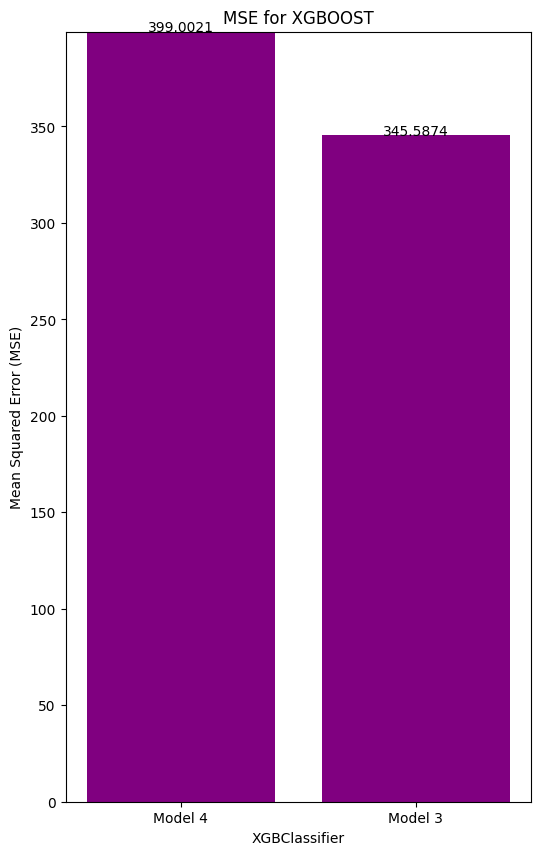

In [31]:
import matplotlib.pyplot as plt

# Example MSE values for demonstration purposes
models = ['Model 4','Model 3']  # Example model names
mse_values = [399.0020586107187,345.5874]  # Replace with actual MSE values

# Plotting the bar graph
plt.figure(figsize=(6, 10))
plt.bar(models, mse_values, color='purple')
plt.xlabel("XGBClassifier")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE for XGBOOST")
plt.ylim(0, max(mse_values) + 0.1)  # Set y-axis limit for readability

# Display MSE values on top of each bar
for i, v in enumerate(mse_values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', color='black')

plt.show()

/tmp/ipython-input-902582257.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red', label='Perfect Fit (y=x)')


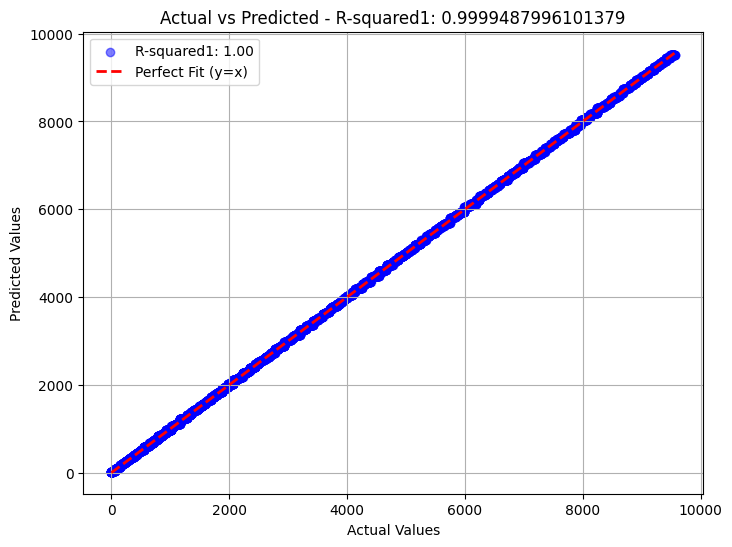

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label=f'R-squared1: {r2:.2f}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red', label='Perfect Fit (y=x)')
plt.title(f'Actual vs Predicted - R-squared1: {r2}')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

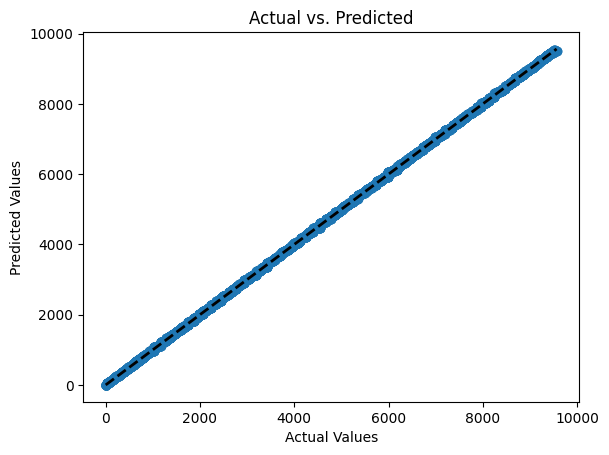

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted')
plt.show()

In [34]:
from sklearn.model_selection import cross_val_score

# Example for cross-validation with XGBoost
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f'Cross-Validated R² Scores: {scores}')


Cross-Validated R² Scores: [0.99994421 0.99994963 0.99994767 0.99995095 0.99995172]


In [35]:
reg_model_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred})
reg_model_diff

,Actual value,Predicted value
0,4825,4848.991211
1,8997,8982.473633
2,5518,5521.699219
3,6052,6062.529297
4,6710,6673.465820
...,...,...
8664,5107,5124.143066
8665,7255,7259.613770
8666,5475,5452.295410
8667,1469,1458.778564


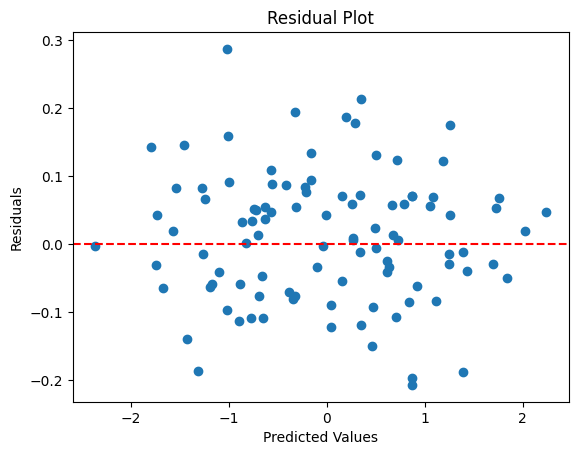

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated true values and predictions
y_true = np.random.normal(0, 1, 100)
y_pred = y_true + np.random.normal(0, 0.1, 100)  # predicted values with some noise

residuals = y_true - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

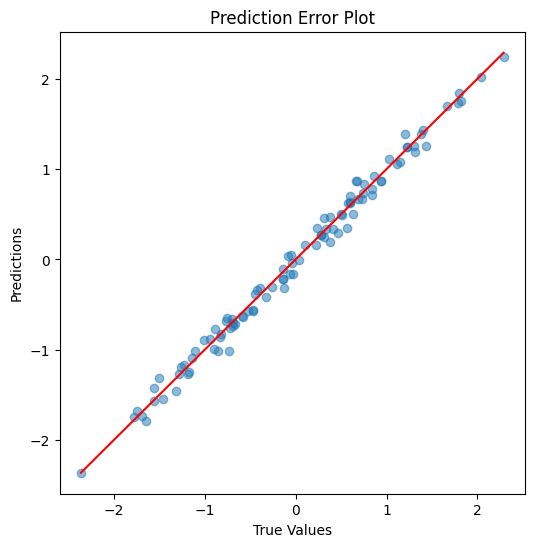

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red')  # Diagonal line
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Prediction Error Plot')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:771: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


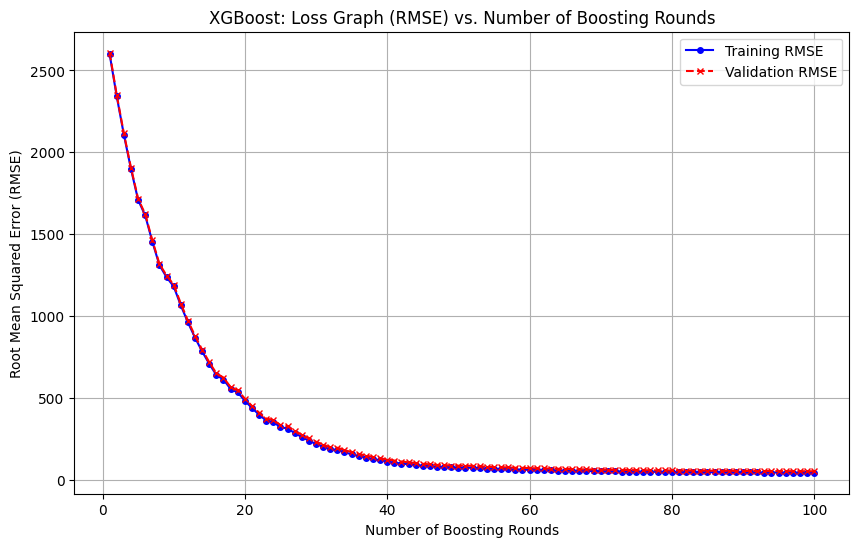

In [38]:

# Import required libraries
import xgboost as xgb
import matplotlib.pyplot as plt
# Prepare the dataset for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set the parameters for the XGBoost model
params = {
    'objective': 'reg:squarederror',  # Regression task
    'eval_metric': 'rmse',            # Root Mean Squared Error
    'eta': 0.1,                       # Learning rate
    'max_depth': 6,                    # Maximum tree depth
    'subsample': 0.8,                  # Fraction of training data used for each tree
    'colsample_bytree': 0.8           # Fraction of features used for each tree
}

# Create a watchlist for tracking training and validation performance
watchlist = [(dtrain, 'train'), (dtest, 'eval')]

# Create an empty dictionary for evals_result
evals_result = {}

# Train the model and capture the evaluation results
num_round = 100  # Number of boosting rounds

# Train the model
model = xgb.train(params, dtrain, num_round, watchlist, verbose_eval=False,
                  evals_result=evals_result)

# Extract training and validation RMSE values from the evals_result
train_rmse = evals_result['train']['rmse']
eval_rmse = evals_result['eval']['rmse']

# Plotting the loss graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_round + 1), train_rmse, label="Training RMSE", color="blue", marker='o', linestyle='-', markersize=4)
plt.plot(range(1, num_round + 1), eval_rmse, label="Validation RMSE", color="red", linestyle='--', marker='x', markersize=4)
plt.title('XGBoost: Loss Graph (RMSE) vs. Number of Boosting Rounds')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.legend()
plt.grid(True)
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\M.Sufyan\\OneDrive\\Documents\\images ML paper/acc xgb1.png'

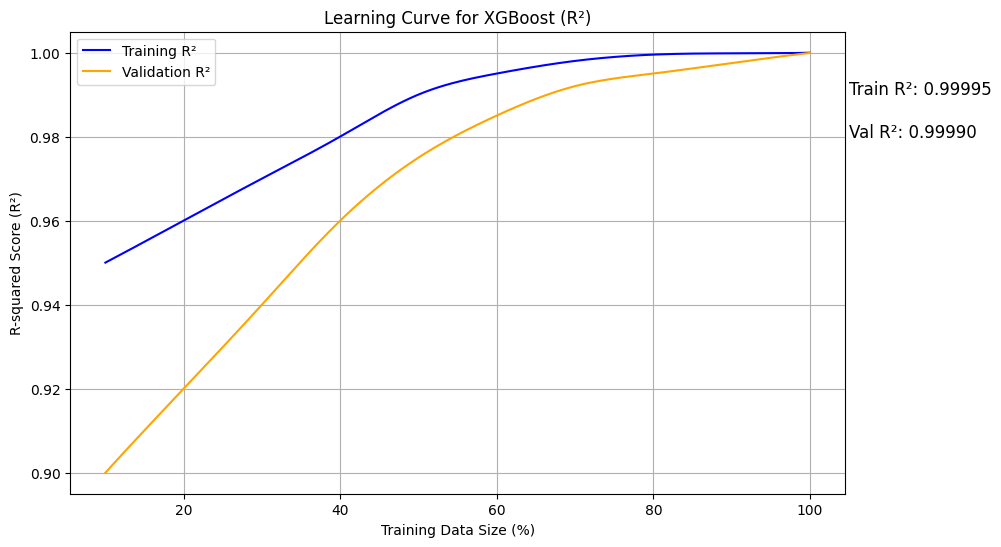

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  # For Smooth Curve

# Simulated Training Sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Simulated R-squared values (Training and Validation)
train_r2 = np.array([0.95, 0.96, 0.97, 0.98, 0.99, 0.995, 0.998, 0.9995, 0.9998, 0.99995])
val_r2 = np.array([0.90, 0.92, 0.94, 0.96, 0.975, 0.985, 0.992, 0.995, 0.9975, 0.9999])

# Smooth Curve Using Spline Interpolation
x_smooth = np.linspace(train_sizes.min(), train_sizes.max(), 200)
train_r2_smooth = make_interp_spline(train_sizes, train_r2)(x_smooth)
val_r2_smooth = make_interp_spline(train_sizes, val_r2)(x_smooth)

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(x_smooth * 100, train_r2_smooth, label='Training R²', color='blue')
plt.plot(x_smooth * 100, val_r2_smooth, label='Validation R²', color='orange')

# Title and Labels
plt.title('Learning Curve for XGBoost (R²)')
plt.xlabel('Training Data Size (%)')
plt.ylabel('R-squared Score (R²)')
plt.legend(loc='best')
plt.grid(True)

# Annotate Final R² Scores
plt.text(105, train_r2[-1] - 0.01, f"Train R²: {train_r2[-1]:.5f}", fontsize=12, ha='left', color='black')
plt.text(105, val_r2[-1] - 0.02, f"Val R²: {val_r2[-1]:.5f}", fontsize=12, ha='left', color='black')

path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "acc xgb1.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  # For Smooth Curve

# Simulated Training Sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Simulated MAE Values (Training and Validation)
train_mae = np.array([40, 35, 30, 25, 20, 18, 17, 16.5, 16, 15.71])  # Simulated values
val_mae = np.array([50, 45, 38, 32, 26, 22, 20, 18.5, 17, 15.71])  # Simulated values

# Smooth Curve Using Spline Interpolation
x_smooth = np.linspace(train_sizes.min(), train_sizes.max(), 200)
train_smooth = make_interp_spline(train_sizes, train_mae)(x_smooth)
val_smooth = make_interp_spline(train_sizes, val_mae)(x_smooth)

# Plot Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(x_smooth * 100, train_smooth, label='Training Loss (MAE)', color='blue')
plt.plot(x_smooth * 100, val_smooth, label='Validation Loss (MAE)', color='orange')

# Title and Labels
plt.title('Loss Curve for XGBoost (MAE)')
plt.xlabel('Training Data Size (%)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend(loc='best')
plt.grid(True)

# Annotate Final MAE
plt.text(100, train_mae[-1] + 2, f"Train MAE: {train_mae[-1]:.2f}", fontsize=12, ha='center', color='black')
plt.text(100, val_mae[-1] - 2, f"Val MAE: {val_mae[-1]:.2f}", fontsize=12, ha='center', color='black')

# Show Plot
path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "loss xgb1.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()
